# Clasificación de Texto con BERT y Hugging Face

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cam2149/icesi-nlp/blob/Entrega4/Sesion4/Entrega4.ipynb)

En este notebook implementaremos un clasificador de noticias de Colombia en español utilizando transformers pero ya basandonos en un modelo pre-entrenado tipo Bidirectional Encoder Representation from Transformers o BERT por sus siglas y disponible en Hugging Face Hub.

El propósito de esta tarea es aprender a utilizar modelos pre-entrenados que por si mismos, sería sumamente costoso entrenar desde cero, tanto por el poder de computo como la disponibilidad de datos de entrenamiento. Entonces gran parte de la labor ya ha sido realizada por nosotros. Nuestra tarea ahora es especializar el modelo en la tarea que tenemos a la mano.

En esta ocasión, vamos a apartarnos de Pytorch Lightning y harémos uso extensivo de la herramientas de Hugging Face, las cuales están especialmente desarrolladas para este tipo de tareas, incluyendo la interacción con modelos pre-entrenados.

#### Referencias
- Dataset: https://huggingface.co/datasets/hacktoberfest-corpus-es/colmbian_spanish_news
- [BETO: Spanish BERT](https://huggingface.co/dccuchile/bert-base-spanish-wwm-cased)
- [BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding](http://arxiv.org/abs/1810.04805)
- [Natural Language Processing with Transformers: Building Language Applications With Hugging Face](https://www.amazon.com/Natural-Language-Processing-Transformers-Applications/dp/1098103246)
- [Hugging Face Transformers](https://huggingface.co/docs/transformers/v4.41.3/en/index)
- [Hugging Face Accelerate](https://huggingface.co/docs/accelerate/index)
- [Hugging Face Evaluate](https://huggingface.co/docs/evaluate/v0.4.0/en/index)
- [Hugging Face Datasets](https://huggingface.co/docs/datasets/v2.19.0/en/index)

In [1]:
import pkg_resources
import warnings

warnings.filterwarnings('ignore')

installed_packages = [package.key for package in pkg_resources.working_set]
IN_COLAB = 'google-colab' in installed_packages

/tmp/ipython-input-2396000874.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


In [2]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


In [3]:
#!test '{IN_COLAB}' = 'True' && wget  https://github.com/Ohtar10/icesi-nlp/raw/refs/heads/main/requirements.txt && pip install -r requirements.txt
!test '{IN_COLAB}' = 'True' && sudo apt-get update -y
!test '{IN_COLAB}' = 'True' && sudo apt-get install python3.10 python3.10-distutils python3.10-lib2to3 -y
!test '{IN_COLAB}' = 'True' && sudo update-alternatives --install /usr/local/bin/python python /usr/bin/python3.11 2
!test '{IN_COLAB}' = 'True' && sudo update-alternatives --install /usr/local/bin/python python /usr/bin/python3.10 1
!test '{IN_COLAB}' = 'True' && pip install lightning datasets 'transformers[torch]' sentence-transformers torchinfo evaluate

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [80.4 kB]
Hit:6 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,241 kB]
Get:8 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease [24.3 kB]
Get:9 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,002 kB]
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy/main amd64 Packages [43.0 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,7

In [4]:
import torch

# Verificar si hay GPU disponible y definir el dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

# Ejemplo de creación de tensor y traslado a GPU
tensor = torch.randn(3, 3)  # Tensor aleatorio
tensor = tensor.to(device)  # Transferir a GPU si está disponible

Usando dispositivo: cpu


### Cargando el dataset
Este es un dataset pequeño de articulos Colombianas de noticias en idioma español con sus respectivas categorías. El dataset está disponible en el HuggingFace Hub y puede ser fácilmente descargado con la librería.
train 60.9k registros
test  3.05k registros
valid 12.2k registros


In [5]:
import pkg_resources
import warnings
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
# Cargar el dataset de Amazon Reviews
from datasets import load_dataset


warnings.filterwarnings("ignore")
# Cargar el dataset neonwatty/amazon_reviews_multi
print("Cargando dataset de Colombian Spanish News...")
dataset = load_dataset('hacktoberfest-corpus-es/colmbian_spanish_news', split='train')
dataset.set_format(type="pandas")
df = dataset.to_pandas()
print("Estructura del dataset:")
print(df)
print("\nEjemplo de muestra:")
df.head()

Cargando dataset de Colombian Spanish News...


README.md:   0%|          | 0.00/877 [00:00<?, ?B/s]

data/train-00000-of-00001-5c45a0f6b5cce2(…):   0%|          | 0.00/157M [00:00<?, ?B/s]

data/test-00000-of-00001-ba9f365147e3f1c(…):   0%|          | 0.00/7.79M [00:00<?, ?B/s]

data/valid-00000-of-00001-1570766e652a35(…):   0%|          | 0.00/31.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60920 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3047 [00:00<?, ? examples/s]

Generating valid split:   0%|          | 0/12184 [00:00<?, ? examples/s]

Estructura del dataset:
                                    news_id  \
0      8a673cad-5548-4991-981d-7b3dd37be9e7   
1      c12930aa-d506-468a-bbe5-224a8154fcae   
2      5449c762-d39f-465e-a0c9-32fc4feef27b   
3      643e3e3a-6148-4781-ad0c-55711597fc8b   
4      ae8b6ce6-f554-4c17-8814-a137191ca253   
...                                     ...   
60915  59363822-b05b-4ff2-b202-c11ccdc1f3ce   
60916  3af44656-d0c6-4050-9c53-25edb110e3d1   
60917  cc63fd11-6e21-483a-a434-175bc44e7d8f   
60918  5ce3e7fc-11b5-44f3-92f0-e23deea6d723   
60919  9d679b1d-d4e6-4540-a2a2-4024e259b33e   

                                       news_url_absolute news_init_date  \
0      https://semana.com/gente/articulo/en-una-cerem...     2022-07-03   
1      https://smoda.elpais.com/moda/actualidad/del-r...     2021-10-02   
2      https://www.valoraanalitik.com/2021/01/22/codi...     2021-01-22   
3      https://semana.com/vida-moderna/articulo/los-f...     2022-10-04   
4      https://elpais.com/diario/200

,news_id,news_url_absolute,news_init_date,news_final_date,news_title,news_text_content,entailment,category,__index_level_0__
0,8a673cad-5548-4991-981d-7b3dd37be9e7,https://semana.com/gente/articulo/en-una-cerem...,2022-07-03,2022-07-03,En una ceremonia “secreta” se casó la presenta...,El matrimonio se celebró en la ciudad de Barra...,1.0,gente,3008
1,c12930aa-d506-468a-bbe5-224a8154fcae,https://smoda.elpais.com/moda/actualidad/del-r...,2021-10-02,2021-10-02,Del relevo de Amancio Ortega al éxito de las m...,El principio del fin de Amaya Arzuaga. El muti...,1.0,innovación,4605
2,5449c762-d39f-465e-a0c9-32fc4feef27b,https://www.valoraanalitik.com/2021/01/22/codi...,2021-01-22,2021-01-22,Codirectora Soto: Colombia debe continuar refo...,En el marco del evento Perspectivas Colombia 2...,1.0,macroeconomia,3295
3,643e3e3a-6148-4781-ad0c-55711597fc8b,https://semana.com/vida-moderna/articulo/los-f...,2022-10-04,2022-10-04,Los factores por los que aumenta el nivel de á...,Cuando los niveles de ácido úrico son elevados...,1.0,gente,1192
4,ae8b6ce6-f554-4c17-8814-a137191ca253,https://elpais.com/diario/2005/09/17/catalunya...,2005-09-17,2005-09-17,Trampeando con la alianza de civilizaciones,"Me dirán que, ante el malismo de otros, bienve...",0.5,alianzas,942


In [6]:
import numpy as np

# Crear un diccionario que asocia IDs únicos a cada categoría en 'df['category']'
id2category = dict(enumerate(np.unique(df['category'])))
# Invertir el diccionario anterior para crear un mapeo de categoría a ID
category2id = {v: k for k, v in id2category.items()}

# Añadir una nueva columna 'category_id' al DataFrame que contiene el ID asociado a cada categoría
df['category_id'] = df['category'].apply(lambda x: category2id[x])
# Reordenar las columnas del DataFrame y mezclar aleatoriamente las filas
df = df[['news_text_content', 'category', 'category_id']].sample(frac=1).reset_index(drop=True)
# Mostrar las primeras filas del DataFrame
df.head()


,news_text_content,category,category_id
0,La Exposición Universal de Dubái comenzó con u...,innovación,3
1,El Departamento Administrativo Nacional de Est...,macroeconomia,4
2,El Consejo de Supervisión del Banco Central Eu...,innovación,3
3,"El Grupo Aval, fundado por el banquero Luis Ca...",reputacion,7
4,"En 1978, el Seat 127 Fura era el rey de las ca...",alianzas,0


In [7]:
# Ordenar el DataFrame por la longitud del contenido de 'news_text_content' en orden descendente
df = df.sort_values(by='news_text_content', key=lambda x: x.str.len(), ascending=False).reset_index(drop=True)

# Mostrar las primeras filas del DataFrame ordenado
df.head()


,news_text_content,category,category_id
0,DINERO ha seleccionado los cien personajes mas...,alianzas,0
1,Los extranjeros que vienen al país coinciden e...,alianzas,0
2,Abril 25 de 2012\r\n\r\nTop Chef\r\n\r\nEl res...,alianzas,0
3,Las cláusulas de permanencia eran un recurso q...,regulaciones,6
4,Bitácora de las elecciones:\r\n\r\n\r\n\r\nJue...,alianzas,0


En esta ocasión, vamos a explorar un poco más las características del dataset a manera ilustrativa.

Primero, observemos la distribución de las clases:

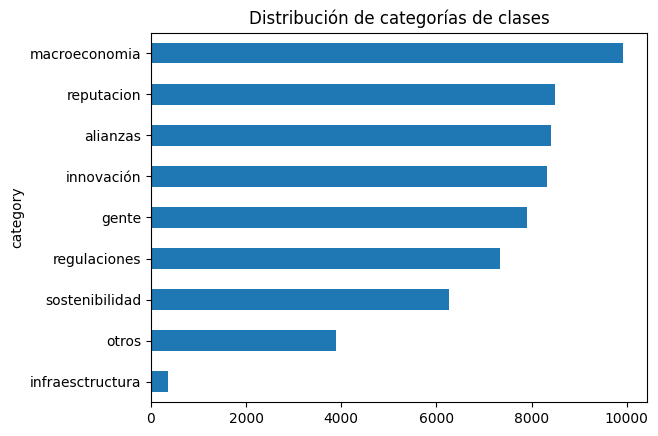

In [8]:
import matplotlib.pyplot as plt

# Visualizar la distribución de clases en el DataFrame mediante un gráfico de barras horizontales
# La función value_counts() cuenta la cantidad de ocurrencias de cada categoría
# con ascending=True, los cuenta en orden ascendente (de menor a mayor)
df.category.value_counts(ascending=True).plot.barh()

# Añadir un título a la gráfica para indicar qué representa
plt.title('Distribución de categorías de clases')

# Mostrar la gráfica generada
plt.show()


In [9]:
# Contar la cantidad de ocurrencias de cada categoría en la columna 'category'
df.category.value_counts()

,count
category,
macroeconomia,9927
reputacion,8501
alianzas,8416
innovación,8330
gente,7906
regulaciones,7341
sostenibilidad,6257
otros,3880
infraesctructura,362


Observamos que es un dataset desbalanceado.

Ahora observemos la dispersión de las palabras por cada categoría.

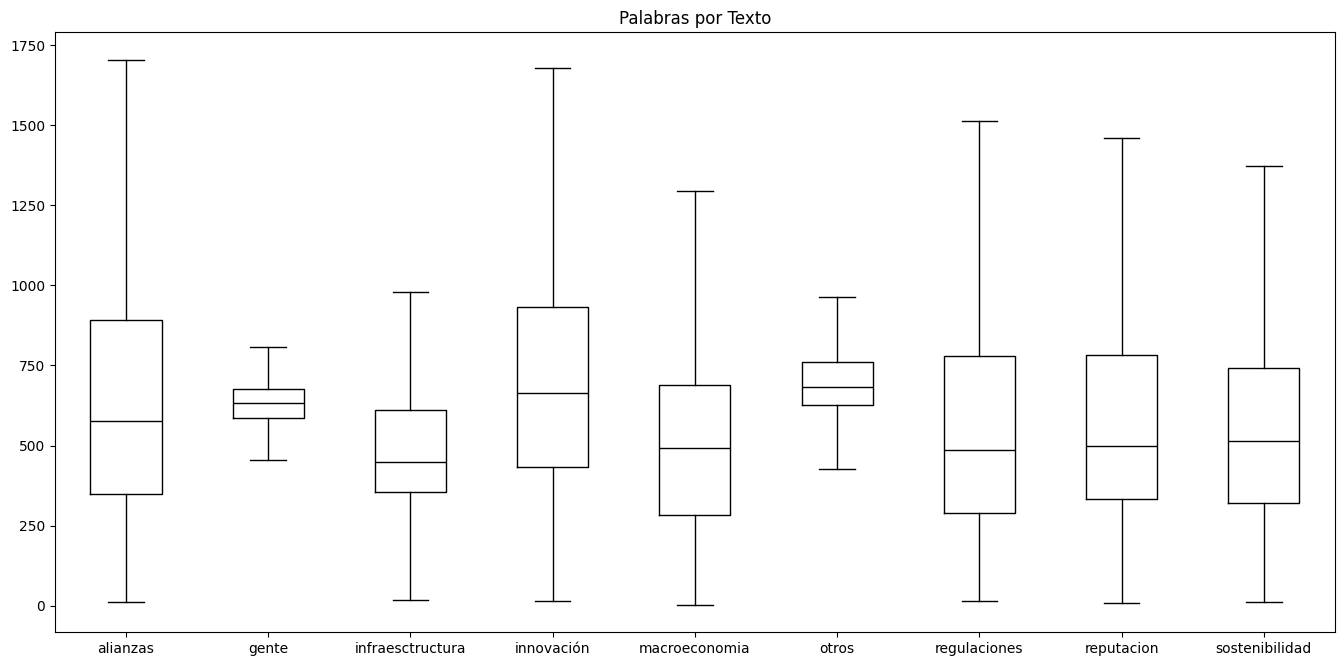

In [10]:
df['Palabras por Texto'] = df['news_text_content'].str.split().apply(len)
df.boxplot('Palabras por Texto', by='category', grid=False, showfliers=False, color='black', figsize=(16, 8))
plt.suptitle('')
plt.xlabel('')
plt.show()

Aquí observamos mayor diversidad. Observamos que algunas clases tienden a tener más palabras que otras, e incluso algunas tienen outliers en cuanto a la longitud de los textos. Sin embargo, como nuestra tarea es de clasificación según el texto y durante el entrenamiento vamos a manejar cadenas de tamaño fijo, lo que nos debería importar más que todo es la media/mediana entre todas las categorías.

In [11]:
df.groupby('category')['Palabras por Texto'].median()

,Palabras por Texto
category,
alianzas,576.0
gente,633.0
infraesctructura,447.5
innovación,662.5
macroeconomia,492.0
otros,684.0
regulaciones,487.0
reputacion,499.0
sostenibilidad,515.0


Como podemos observar, la mediana, que como media de tendencia central, tiende a ser más robusta que la media, nos indica que la longitud mediana de los textos entre todas las categorías tiende a rondar por las $\approx555$ palabras. Entonces utilizaremos una longitud de texto acorde durante nuestro entrenamiento.

In [12]:
# Restablecer el formato del dataset a su estado original o eliminar cualquier formato personalizado
dataset.reset_format()

### Definiendo el Tokenizer

Como la idea en este notebook es la de re-utilizar modelos pre-entrenados, algo a tener en cuenta es que para que esto funcione correctamente, debemos **siempre** utilizar el mismo tokenizador que se usó para entrenar el modelo. Recordemos que el tokenizador asigna un código a cada token del vocabulario, y durante la creación de los embeddings, el modelo asume esto como entrada, por lo que su usamos otro tokenizador, el modelo va a ser incapaz de derivar las relaciones semánticas apropiadas.

Para esta tarea, haremos uso de un modelo BERT pre-entrenado en corpus del idioma español. El modelo puede ser encontrado [aquí](https://huggingface.co/dccuchile/bert-base-spanish-wwm-cased), es un modelo entrenado por el [Departamento de Ciencias de la Computación de la Universidad de Chile](https://www.dcc.uchile.cl), el cual según los autores, fue entrenado en un gran corpus de idioma español por lo que resulta un buen candidato para la tarea en cuestión.

Este código carga un tokenizador basado en BERT en español que ha sido entrenado con Whole Word Masking (WWM). Es útil para preparar datos de texto antes de alimentar modelos de transformers.

In [13]:
# Importar la clase AutoTokenizer de transformers para cargar el tokenizador preentrenado
from transformers import AutoTokenizer

# Especificar el nombre del modelo preentrenado en Hugging Face
model_ckpt = "dccuchile/bert-base-spanish-wwm-cased"

# Cargar el tokenizador asociado al modelo preentrenado
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)


tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

Ahora sometamos a prueba el tokenizador con la misma frase del notebook anterior.

Este bloque de código ajusta el token de padding y realiza una tokenización con relleno y truncamiento para que la secuencia tenga exactamente 10 tokens.



In [14]:
# Este código obtiene y muestra la cantidad total de tokens en el vocabulario del tokenizer.
# Establecer manualmente el token de padding del tokenizer a '[PAD]'
tokenizer.pad_token = '[PAD]'

# Tokenizar la secuencia "hola mundo!!" con un máximo de 10 tokens,
# truncando si es necesario, y rellenando hasta la longitud máxima
tokens = tokenizer("hola mundo!!", max_length=10, truncation=True, padding='max_length').tokens()

# Mostrar los tokens resultantes
print(tokens)


['[CLS]', 'hola', 'mundo', '!', '!', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


Algo interesante, este tokenizador, por lo menos para las palabras de esta frase de prueba, no separa en tokens distintos estas palabras, esto es justamente la razón por la cual no deberíamos usar un tokenizador diferente con un modelo pre-entrenado, habríamos obtenido tokens diferentes y el modelo no lograría interpretar la semantica como se espera.

Ahora, observemos su vocabulario.

In [15]:
# Obtener el tamaño del vocabulario del tokenizer
vocab_size = tokenizer.vocab_size

# Mostrar el tamaño del vocabulario
print(vocab_size)


31002


Tenemos $31002$ tokens, es una cantidad inferior que el modelo manual que intentamos en la lección anterior, pero lo suficientemente amplio para una tarea de NLP.

Ahora, observemos otros parámetros del tokenizador.

In [16]:
# Obtener la longitud máxima de la secuencia que el modelo puede procesar
model_max_length = tokenizer.model_max_length

# Mostrar la longitud máxima del modelo
print(model_max_length)


512


In [17]:
# Obtener los nombres de entrada que espera el tokenizer (generalmente ['input_ids', 'attention_mask'])
model_input_names = tokenizer.model_input_names

# Mostrar los nombres de las entradas del modelo
print(model_input_names)


['input_ids', 'token_type_ids', 'attention_mask']


Primero, observamos que el tokenizador por defecto maneja un tamaño de secuencia de $512$, convenientemente al rededor de la misma longitud mediana de nuestro dataset, por lo que resulta perfecto para nuestro caso de uso. Finalmente, observamos sus salidas, las cuales serán las entradas a nuestro modelo. Como ya debemos saber, `input_ids` son los indices de los tokens y `attention_mask` es la máscara de atención cuando tenemos tokens irrelevantes (como el padding) en la cadena.

## Usando un modelo BERT pre-entrenado sencillo

![](https://github.com/cam2149/icesi-advanced-dl/blob/main/assets/bert-architecture.png?raw=1)
![](https://github.com/cam2149/icesi-advanced-dl/blob/main/assets/bert-tokenization.png?raw=1)
Primero, vamos a probar con un modelo pre-entrenado sin mayor modificación a la capa de clasificación. Hugging Face ofrece una clase utilitaria para inicializar el modelo en modo de clasificación de secuencias, lo cual hará que convenientemente tengamos una capa o cabeza de clasificación en el modelo, justo con la cantidad de clases que definamos.

Recordemos que el modelo y el tokenizador deben pertenecer al mismo "paquete", por lo que invocamos a `from_pretrained` con el mismo id que al tokenizer.

Técnicamente hay dos formas de utilizar un modelo pre-entrenado:

1. Como Featurizer: Es decir, vamos a utilizar todas las capas de codificación del modelo **sin re-entrenarlas** o lo que sería lo mismo **congelandolas** haciendo que lo único que vayamos a entrenar sea el clasificador en si.
2. Fine Tuning: Es decir, dejar todas las capas entrenables y entrenar el modelo en su totalidad, a partir del checkpoint del modelo pre-entrenado, para nuestra tarea especifica.

### BERT pre-entrenado como featurizer (simple)

Una ventaja de este enfoque es que es menos costoso de entrenar, a nivel de recursos de computo, ya que no vamos a calcular gradientes para todas las capas sino para la capa de clasificación. Incluso, no es necesario que utilicemos deep learning para la clasificación final, podemos usar algoritmos clasicos, que parten de los embeddings producidos por el modelo pre-entrenado.

Otra ventaja es que debido a que puede ser mucho más rápido de entrenar que no solo un modelo desde cero, sino más rápido que fine tuning, nuevamente, porque ya no es necesario calcular gradientes para todo el modelo, sino solo para la capa de clasificación de nuestro interes.

In [18]:
import torch
from torchinfo import summary
from transformers import AutoModelForSequenceClassification

# Seleccionar el dispositivo: GPU si está disponible, sino CPU
device = "cuda" if torch.cuda.is_available() else "cpu"

# Tokenizar la entrada "hola mundo!!!"
# con máximo de 10 tokens, truncar si excede, rellenar hasta la longitud máxima y devolver tensores PyTorch
inputs = tokenizer(
    "hola mundo!!!",
    max_length=10,
    truncation=True,
    padding='max_length',
    return_tensors='pt'
)

# Mostrar las formas y tipos de datos de los tensores de entrada
print(f"Input Shapes & Types:")
print({k: (v.shape, v.dtype) for k, v in inputs.items()})

# Cargar el modelo de clasificación de secuencias preentrenado y ajustarlo para nuevo número de clases
model = AutoModelForSequenceClassification.from_pretrained(
    model_ckpt,
    num_labels=len(category2id)
).to(device)

# Congelar los pesos del modelo base para que solo se ajusten las capas finales, usándolo como extractor de características
for param in model.base_model.parameters():
    param.requires_grad = False

# Definir el tamaño y el tipo de entrada para el resumen
# Como el modelo espera un batch, replicamos la forma de la entrada tres veces
input_sizes = [inputs['input_ids'].shape] * 3
input_types = [inputs['input_ids'].dtype] * 3

# Realizar un resumen del modelo en modo evaluación sin calcular gradientes
with torch.no_grad():
    print(
        summary(
            model,
            input_size=input_sizes,
            dtypes=input_types,
            col_names=['input_size', 'output_size', 'num_params', 'trainable']
        )
    )



Input Shapes & Types:
{'input_ids': (torch.Size([1, 10]), torch.int64), 'token_type_ids': (torch.Size([1, 10]), torch.int64), 'attention_mask': (torch.Size([1, 10]), torch.int64)}


pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Layer (type:depth-idx)                                       Input Shape               Output Shape              Param #                   Trainable
BertForSequenceClassification                                [1, 10]                   [1, 9]                    --                        Partial
├─BertModel: 1-1                                             [1, 10]                   [1, 768]                  --                        False
│    └─BertEmbeddings: 2-1                                   --                        [1, 10, 768]              --                        False
│    │    └─Embedding: 3-1                                   [1, 10]                   [1, 10, 768]              (23,809,536)              False
│    │    └─Embedding: 3-2                                   [1, 10]                   [1, 10, 768]              (1,536)                   False
│    │    └─Embedding: 3-3                                   [1, 10]                   [1, 10, 768]              (393,216)  

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Observamos que el modelo tiene una capa `BertModel` que corresponde al modelo pre-entrenado y finaliza con una capa lineal que sería nuestro clasificador, esta es una capa proporcionada para nosotros al momento de inicializar el modelo. Además, observamos que solamente la capa lineal que hemos especificado tiene parámetros entrenables. Entonces, a pesar de que el modelo en si tiene más de 100 millones de parámetros `[109,857,801]`, solamente menos de 10 mil son entrenables `[6,921]`.

Observemos todos los modulos registrados en el modelo:

In [19]:
# Obtener la lista de todos los módulos del modelo usando 'named_modules()'
# Esto devuelve un iterador de (nombre, módulo), y se extraen solo los módulos
modules = [m for m, _ in model.named_modules()]

# Mostrar la lista de módulos
modules


['',
 'bert',
 'bert.embeddings',
 'bert.embeddings.word_embeddings',
 'bert.embeddings.position_embeddings',
 'bert.embeddings.token_type_embeddings',
 'bert.embeddings.LayerNorm',
 'bert.embeddings.dropout',
 'bert.encoder',
 'bert.encoder.layer',
 'bert.encoder.layer.0',
 'bert.encoder.layer.0.attention',
 'bert.encoder.layer.0.attention.self',
 'bert.encoder.layer.0.attention.self.query',
 'bert.encoder.layer.0.attention.self.key',
 'bert.encoder.layer.0.attention.self.value',
 'bert.encoder.layer.0.attention.self.dropout',
 'bert.encoder.layer.0.attention.output',
 'bert.encoder.layer.0.attention.output.dense',
 'bert.encoder.layer.0.attention.output.LayerNorm',
 'bert.encoder.layer.0.attention.output.dropout',
 'bert.encoder.layer.0.intermediate',
 'bert.encoder.layer.0.intermediate.dense',
 'bert.encoder.layer.0.intermediate.intermediate_act_fn',
 'bert.encoder.layer.0.output',
 'bert.encoder.layer.0.output.dense',
 'bert.encoder.layer.0.output.LayerNorm',
 'bert.encoder.layer.0

Observamos que la capa final es efectivamente el `classifier`. Ahora hagamos una prueba pasando un dummy input:

In [20]:
# Ejecutar el bloque sin calcular gradientes, ya que estamos en modo evaluación
with torch.no_grad():
    # Mover los tensores de entrada al dispositivo (GPU o CPU)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    # Realizar la inferencia pasándoles los datos al modelo
    outputs = model(**inputs)

# Mostrar las formas de los tensors en el diccionario de salida del modelo
print({k: v.shape for k, v in outputs.items()})


{'logits': torch.Size([1, 9])}


In [21]:
# La variable 'outputs' contiene el resultado de la inferencia del modelo
# Para un modelo de clasificación de secuencias, típicamente incluye:
# - logits: las puntuaciones antes de aplicar la función softmax
# - (opcionalmente) otras salidas como loss si se proporcionan etiquetas durante entrenamiento
#
# Imprimir 'outputs' mostrará un diccionario con estos tensores, ej:
# {'logits': tensor(...), ...}
print(outputs)  # Diccionario con las salidas del modelo: 'logits' (tensor [batch_size, num_labels]) y, si está habilitado, 'hidden_states' y 'attentions'


SequenceClassifierOutput(loss=None, logits=tensor([[ 0.2766,  0.0622,  0.0357,  0.1547,  0.0474,  0.2962, -0.0810, -0.1903,
          0.1128]]), hidden_states=None, attentions=None)


In [22]:
# Acceder a la capa 'classifier' del modelo, que generalmente es la capa final de clasificación
model.classifier # Capa de clasificación final (nn.Linear) que transforma la representación pooled en logits de tamaño num_labels


Linear(in_features=768, out_features=9, bias=True)

Observamos que tras invocar el modelo, en efecto, obtenemos una salida de 9 dimensiones, correspondientes al número de clases.

Ahora preparemos los datos para el entrenamiento.

Hugging Face Datasets convenientemente implementa una función para hacer el train-test splig en nuestro dataset y automáticamente creará nuevas llaves en el mismo para diferenciarlo.

In [23]:
# Dividir el dataset original en conjunto de entrenamiento (80%) y conjunto de prueba (20%)

training_dataset = dataset.train_test_split(train_size=0.8) # Crea un split: 80% train y 20% test a partir del dataset original

# Desde el conjunto de prueba generado anteriormente, dividir en validación y prueba
# La mitad del conjunto de test (que ahora es el 20% inicial) se usará para validación
validation_dataset = training_dataset['test'].train_test_split(train_size=0.5)




In [24]:
# Importar la clase DatasetDict del módulo datasets.dataset_dict
from datasets.dataset_dict import DatasetDict

# Crear un nuevo DatasetDict con los conjuntos de entrenamiento, validación y prueba
new_dataset = DatasetDict({
    'train': training_dataset['train'],         # Conjunto de entrenamiento (80% original)
    'val': validation_dataset['train'],         # Conjunto de validación (10% original)
    'test': validation_dataset['test'],         # Conjunto de prueba (10% original)
})

# Mostrar el DatasetDict resultante
# Ahora tenemos:
# - training_dataset['train']: 80% del dataset original para entrenamiento
# - validation_dataset['train']: 10% del dataset original para validación
# - validation_dataset['test']: 10% del dataset original para pruebas (si quieres usarlo)
new_dataset


DatasetDict({
    train: Dataset({
        features: ['news_id', 'news_url_absolute', 'news_init_date', 'news_final_date', 'news_title', 'news_text_content', 'entailment', 'category', '__index_level_0__'],
        num_rows: 48736
    })
    val: Dataset({
        features: ['news_id', 'news_url_absolute', 'news_init_date', 'news_final_date', 'news_title', 'news_text_content', 'entailment', 'category', '__index_level_0__'],
        num_rows: 6092
    })
    test: Dataset({
        features: ['news_id', 'news_url_absolute', 'news_init_date', 'news_final_date', 'news_title', 'news_text_content', 'entailment', 'category', '__index_level_0__'],
        num_rows: 6092
    })
})

Tenemos nuestros tres conjuntos, sin embargo, esto es la información cruda, debemos preparar los datos para el modelo, lo gual incluye tokenizar y convertir las categorías a ids. Preparamos entonces unas funciones utilitarias.

In [25]:
def preprocess_function(max_len):                         # Devuelve una función que tokeniza ejemplos usando max_len
    def _preprocess_function(examples):                   # Función interna que recibe ejemplos (puede ser batch)
        return tokenizer(examples['news_text_content'],   # Tokeniza el campo 'news_text_content'
                         max_length=max_len,              # Longitud máxima fija
                         truncation=True,                 # Trunca si supera max_len
                         padding='max_length')            # Rellena hasta max_len
    return _preprocess_function                           # Retorna la función preparada

def tokenize(max_len: int = 8):                           # Devuelve una función para tokenizar batches (longitud por defecto 8)
    def _tokenize(batch):                                 # Función interna que opera sobre un batch
        return tokenizer(batch['news_text_content'],      # Tokeniza el campo 'news_text_content' del batch
                         max_length=max_len,              # Longitud máxima
                         truncation=True,                 # Truncamiento activado
                         padding='max_length')            # Padding hasta max_len
    return _tokenize                                      # Retorna la función de tokenización

def category_names_2_ids(batch):                          # Convierte nombres de categoría a IDs numéricos en el batch
    batch['label'] = category2id[batch['category']]       # Asigna columna 'label' usando el mapping category2id
    return batch

Y procedemos a invocarlas. Nótese que para la tokenización, estamos forzando a que las cadenas sean de 512 tokens, según el análisis que hemos hecho anteriormente.

In [26]:
# Aplicar la función de preprocesamiento a todo el dataset en modo batch,
# limitando la longitud de las secuencias a 512 tokens
tokenized_dataset = new_dataset.map(preprocess_function(max_len=512), batched=True)

# Mapear las categorías a IDs en todo el dataset usando la función definida anteriormente
tokenized_dataset = tokenized_dataset.map(category_names_2_ids)

# Mostrar el dataset tokenizado y con las categorías convertidas a IDs
tokenized_dataset


Map:   0%|          | 0/48736 [00:00<?, ? examples/s]

Map:   0%|          | 0/6092 [00:00<?, ? examples/s]

Map:   0%|          | 0/6092 [00:00<?, ? examples/s]

Map:   0%|          | 0/48736 [00:00<?, ? examples/s]

Map:   0%|          | 0/6092 [00:00<?, ? examples/s]

Map:   0%|          | 0/6092 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['news_id', 'news_url_absolute', 'news_init_date', 'news_final_date', 'news_title', 'news_text_content', 'entailment', 'category', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask', 'label'],
        num_rows: 48736
    })
    val: Dataset({
        features: ['news_id', 'news_url_absolute', 'news_init_date', 'news_final_date', 'news_title', 'news_text_content', 'entailment', 'category', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask', 'label'],
        num_rows: 6092
    })
    test: Dataset({
        features: ['news_id', 'news_url_absolute', 'news_init_date', 'news_final_date', 'news_title', 'news_text_content', 'entailment', 'category', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask', 'label'],
        num_rows: 6092
    })
})

#### Entrenamiento

Ahora procederemos al entrenamiento. Aquí harémos uso de las API de HuggingFace directamente.

In [27]:
from transformers import AutoModelForSequenceClassification
from transformers import Trainer, TrainingArguments
from typing import Dict, Any
import evaluate

# Cargar la métrica de precisión 'accuracy' para evaluar el rendimiento del modelo
accuracy = evaluate.load("accuracy")

# Definir una función que calcula y retorna métricas de evaluación (precisión en este caso)
def compute_metrics(pred) -> Dict[str, Any]:
    """compute metrics

    Esta función será invocada en cada época durante el entrenamiento
    y se usará para calcular la métrica de calidad del modelo.
    """
    # Obtener las etiquetas verdaderas
    labels = pred.label_ids
    # Obtener las predicciones y seleccionar la clase con mayor puntuación
    preds = pred.predictions.argmax(-1)
    # Calcular la precisión comparando las predicciones con las etiquetas reales
    acc = accuracy.compute(predictions=preds, references=labels)
    # Retornar la métrica en forma de diccionario
    return acc

# Definir el tamaño de batch dependiendo del entorno (Colab o local)
batch_size = 8 if IN_COLAB else 4

# Calcular cuántos pasos de logging habrá en cada época
logging_steps = len(tokenized_dataset['train']) // batch_size

# Definir los argumentos de entrenamiento, como duración, tasa de aprendizaje, batch size, etc.
training_args = TrainingArguments(
    output_dir='./hf',                 # Directorio donde se guardarán los modelos y logs
    num_train_epochs=2,                # Número de épocas para entrenar
    learning_rate=2e-5,                # Tasa de aprendizaje
    per_device_eval_batch_size=batch_size,  # Batch size para evaluación
    per_device_train_batch_size=batch_size, # Batch size para entrenamiento
    weight_decay=0.01,                 # Decaimiento del peso para regularización
    eval_strategy='epoch',       # Evaluar al final de cada época # Corrected parameter name
    save_strategy='epoch',             # Guardar el modelo al final de cada época
    load_best_model_at_end=True,       # Cargar el mejor modelo al final del entrenamiento
    disable_tqdm=False,                # Mostrar barras de progreso
    logging_steps=logging_steps        # Pasos entre registros de logs
)

# Crear un objeto Trainer con el modelo, args, datasets, tokenizador y métrica
trainer = Trainer(
    model=model,                        # Modelo a entrenar
    args=training_args,                 # Argumentos de entrenamiento
    compute_metrics=compute_metrics,   # Función para calcular métricas
    train_dataset=tokenized_dataset['train'],  # Dataset de entrenamiento
    eval_dataset=tokenized_dataset['val'],     # Dataset de validación
    tokenizer=tokenizer                 # Tokenizador utilizado
)

Con esto nos basta para ejecutar el entrenamiento:

In [ ]:
trainer.train()

<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: cam2149 (cam2149-universidad-icesi) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss


Algo importante a resaltar es que fueron necesarias solo 2 iteraciones para alcanzar un ta tasa de correctitud $\approx 79%$, algo que con el modelo de transformers crudo nos costó muchas más iteraciones. Esto demuestra la importancia de partir de modelos pre-entrenados para este tipo de tareas.

Una ventaja adicional de Hugging Face transformers, es que publica automáticamente el progreso del entrenamiento a tensorboard, en el directorio que hemos especificado. Observemos entonces el proceso de entrenamiento:

In [ ]:
%load_ext tensorboard

In [ ]:
%tensorboard --logdir hf/runs

Y ahora evaluemos el modelo en el conjunto de prueba:

In [ ]:
model.eval()
trainer.evaluate(tokenized_dataset['test'])

Hemos alcanzado una correctitud del $\approx 80\%$, lo cual, nuevamente, en comparación con el modelo de transformers crudo nos costó muchisimo más lograr.

### Haciendo uso del modelo
Ahora, hagamos predicciónes con el modelo y observemos los resultados.

In [ ]:
predictions = trainer.predict(tokenized_dataset['test'])
predictions

In [ ]:
predicted_labels = np.argmax(predictions.predictions, axis=-1)
test_set = tokenized_dataset['test']
test_set = test_set.add_column('prediction_label', predicted_labels)
test_set = test_set.add_column('prediction', list(map(lambda label: id2category[label], predicted_labels)))
test_set

In [ ]:
columns = ['text', 'label', 'prediction_label', 'category', 'prediction']
test_set.set_format('pandas', columns=columns)
df = test_set.to_pandas()[columns]
df.style.set_table_styles(
    [
        {'selector': 'td', 'props': [('word-wrap', 'break-word')]}
    ]
)
df.head(15)

Los resultados no lucen nada mal, aún se cometen un par de errores, pero de resto, parece bastante aceptable. Observemos los errores.

In [ ]:
errors = df[df['label'] != df['prediction_label']]
errors.head(15)

Los errores parece que son mucho más interesantes que en nuestro mdelo pasado.

Los errores parecen algo mucho más genuino, economía y política son categorías que tienen algo de superposición entre si, al igual que motor y deportes, según sea el caso.

## Usando una capa más especializada como clasificador

Quizás podemos hacerlo mejor, hemos observado que por defecto, cuando cargamos la clase, Hugging Face nos da un clasificador muy simple, solo una capa lineal. Pero podemos utilizar un clasificador más complejo que definamos nosotros. Esta técnica seguiría utilizando el resto del modelo como featurizer, pero ahora añadimos complejidad a la capa de clasificación en búsqueda de una mejor calidad en los resutlados.

Entonces, volvemos a cargar el modelo tal como hemos hecho antes:

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=len(category2id)).to(device)

for param in model.base_model.parameters():
    param.requires_grad = False


input_sizes = [inputs['input_ids'].shape] * 3
input_types = [inputs['input_ids'].dtype] * 3
with torch.no_grad():
    print(summary(model, input_size=input_sizes, dtypes=input_types, col_names=['input_size', 'output_size', 'num_params', 'trainable']))

In [ ]:
model.classifier

### Definimos un clasificador propio

Podemos definir cualquier tipo de clasificador que se nos ocurra, siempre que se ajuste a las entradas y salidas del clasificador existente. Vamos a utilizar por ejemplo la misma capa lineal que definimos en el notebook anterior:

In [ ]:
import torch.nn as nn


classifier = nn.Sequential(
    nn.Linear(768, 512),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256, 12),
    nn.LogSoftmax(dim=1)
)

# simplemente reemplazamos el clasificador existente por el nuestro:
model.classifier = classifier
with torch.no_grad():
    print(summary(model, input_size=input_sizes, dtypes=input_types, col_names=['input_size', 'output_size', 'num_params', 'trainable']))

Observamos que nuestro modelo ya tiene más parámetros para entrenar, producto de nuestro nuevo clasificador.

Procedemos a definir nuevamente el entrenador.

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['val'],
    tokenizer=tokenizer
)

Y a entrenar el modelo

In [ ]:
%%time

trainer.train()

Y evaluamos el resultado:

In [ ]:
model.eval()
trainer.evaluate(tokenized_dataset['test'])

Hemos obtenido una ligera mejora en nuestro modelo, lo cual sugiere que nuestro clasificador más complejo contribuye a una mayor calidad de los resultados.

## Fine Tuning con BERT

Para terminar, ahora harémos fine tuning, es decir, vamos a dejar libres todas las capas del modelo base para que todas calculen gradiente y entrenen sobre nuestra tarea específica.

En este caso entonces no necesitamos modificar nada del modelo original, podemos instanciarlo y proceder directamente al entrenamiento:

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=len(category2id)).to(device)
trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['val'],
    tokenizer=tokenizer
)

In [ ]:
%%time
trainer.train()

In [ ]:
model.eval()
trainer.evaluate(tokenized_dataset['test'])

Hemos alcanzado una correctitud superior al $\approx 90\%$ en el conjunto de prueba!

Con fine tuning, todas las capas del modelo ajustarán sus parámetros en respuesta al proceso de entrenamiento, por lo que es natural que la calidad de los resultados se incremente significativamente. Sin embargo, no hay que abusar del fine tuning ya que tiende a hacer overfitting al conjunto con el que se entrena, por eso también es recomendable no entrenarlo demasiado.

## Conclusiones
- Trabajar con modelos pre-entrenados supone una mejora no solo en la calidad de los resultados, sino en los tiempos de entrenamiento y esfuerzo requerido para la labor.
- En general, particularmente con modelos de lenguaje, dado lo costoso que puede resultar su entrenamiento desde cero, a día de hoy es mejor empezar con un modelo pre-entrenado y hacer bien transfer learning o fine tuning.
- Implementar modelos nuevos tiene sentido cuando la tarea en cuestión es particularmente novedosa o definitivamente no se cuenta con un modelo pre-entrenado que por lo menos capture parte del contexto requerido para la tarea. Ejemplos de esto puede ser una tarea en un idioma para el cual no exista aún un modelo fundacional, o que los existentes hayan sido entrenados en un corpus limitado o sesgado a un campo de dominio por ejemplo, ciertamente sería difícil obtener resultados de buena calidad para un modelo de clasificación en el ámbito legal, partiendo de un modelo entrenado exclusivamente en el ámbito clínico.
- Dentro de las posibilidades de usar un modelo pre-entrenado en forma de transfer learning o fine tuning, si fine tuning es superior, porque molestarse con las otras formas? porque no siempre se va a contar con los recursos (datos, computo y tiempo) para hacer fine tuning, o por ejemplo, en el runtime objetivo no se cuenta con GPU, por lo que quizás sea más factible usar modelos clásicos. Cada situación merece analizarse para hallar el mejor modo a implementar.